In [465]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [466]:
#Importation du data set
data= pd.read_csv("weather_forecast_data.csv")

In [467]:
#data.head()


In [468]:
#Encodage de la cible : on encode la vari
data["Rain"]= data["Rain"].map({"no rain": 0, "rain": 1})


In [469]:
type(data)

pandas.core.frame.DataFrame

In [470]:
#data.head()

In [471]:
#print(data)


In [472]:
#print(data.isnull().sum())

In [473]:
#print(data.duplicated().sum())

In [474]:
#from scipy import stats

#z = stats.zscore(data["Temperature"])
#outliers = data[(z > 3) | (z < -3)]

In [475]:
#outliers = data[(z > 3) | (z < -3)]
#print(outliers)

In [476]:
#sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
#plt.show()
#correlation

In [477]:
X = data[["Temperature","Humidity","Cloud_Cover"]]
Y = data["Rain"]

In [478]:
m = len(X)
indices = np.random.permutation(m)
train_size = int(0.75* m)     # 75% pour l'entraînement
val_size = int(0.05 * m)      # 5% pour la validation
# Le reste (environ 20%) ira au test


train_idx = indices[:train_size]
val_idx = indices[train_size : train_size + val_size]
test_idx = indices[train_size + val_size :]

X_train = X.iloc[train_idx].reset_index(drop=True)
Y_train = Y.iloc[train_idx].reset_index(drop=True)

# Ensemble de Validation
X_val = X.iloc[val_idx].reset_index(drop=True)
Y_val = Y.iloc[val_idx].reset_index(drop=True)

# Ensemble de Test
X_test = X.iloc[test_idx].reset_index(drop=True)
Y_test = Y.iloc[test_idx].reset_index(drop=True)



In [479]:
print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

(1875, 3)
(125, 3)
(500, 3)


In [480]:
trainset_size  = len(X_train)
valset_size = len(X_val)

In [481]:
print(X_train.values.shape)

(1875, 3)


In [482]:
mean = X_train.mean()
std = X_train.std()
X_train = (X_train - mean) / std
X_val = (X_val - mean) / std
X_test = (X_test - mean) / std

In [483]:
def sigmoid(z) : 
    return 1/(1+np.exp(-z))


In [484]:
#print(X_train)
#print(Y_train.values.reshape(-1,1).shape)
#print(a)

In [485]:
y = Y_train.values.reshape(-1,1)

In [486]:
#fonction cout (log-loss)
def J(a,y) :
    epsilon = 1e-15
    a = np.clip(a, epsilon, 1-epsilon)
    m = len(y) 
    return -1/m * np.sum(y*np.log(a) + (1-y)*np.log(1-a))

In [487]:
#def J(a,Y_train) :
    #return -(1/m)*(Y_train.values.reshape(-1,1) @ np.log(a) + (1-Y_train.values.reshape(-1,1)) @ np.log(1-a))

In [488]:
#pas d'apprentissage
p=0.01


In [489]:
print(X_train.values.reshape(-1,1))

[[-0.0084002 ]
 [ 1.45029486]
 [ 0.23454891]
 ...
 [-0.87488195]
 [ 1.36537961]
 [ 1.25595359]]


In [490]:
print(y.shape)
n = X_train.shape[1]
train_costs = []
val_costs = []
w = np.zeros((n,1))
b = 0
print(w)

(1875, 1)
[[0.]
 [0.]
 [0.]]


In [491]:
for i in range(10000):
    z_train = X_train.values @ w + b
    a_train = sigmoid(z_train)
    y_true_train = Y_train.values.reshape(-1, 1)

    current_train_cost = J(a_train, y_true_train)
    train_costs.append(current_train_cost)

    z_val = X_val.values @ w + b
    a_val = sigmoid(z_val)
    y_true_val = Y_val.values.reshape(-1,1)

    current_val_cost = J(a_val, y_true_val)
    val_costs.append(current_val_cost)

    dw = (1/trainset_size) * X_train.values.T @ (a_train - Y_train.values.reshape(-1,1))
    db = (1/trainset_size) * np.sum(a_train - Y_train.values.reshape(-1,1))
    
    w = w - p * dw
    b = b - p * db

In [492]:
print(w)

[[-1.29095396]
 [ 1.75644006]
 [ 1.60166775]]


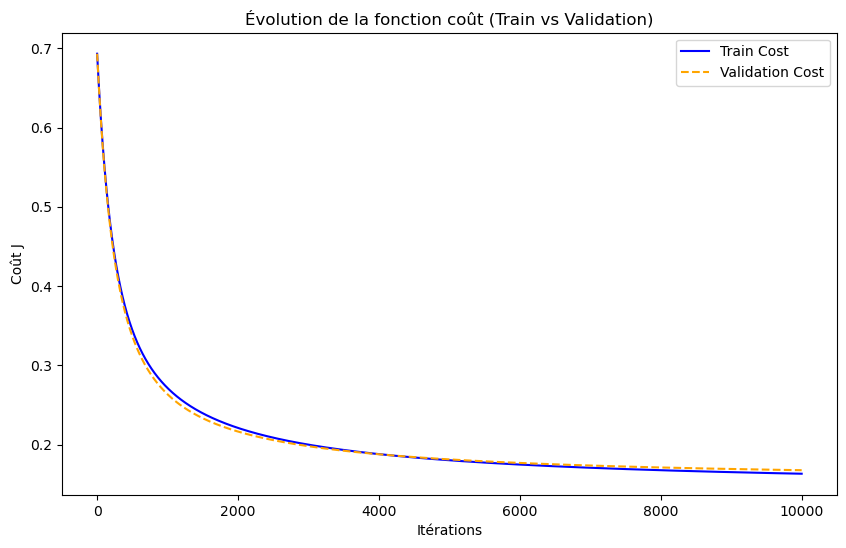

In [493]:
# 5. Affichage du graphique comparatif (Source [5, 6])
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train Cost", color='blue')
plt.plot(val_costs, label="Validation Cost", color='orange', linestyle='--')
plt.title("Évolution de la fonction coût (Train vs Validation)")
plt.xlabel("Itérations")
plt.ylabel("Coût J")
plt.legend()
plt.show()

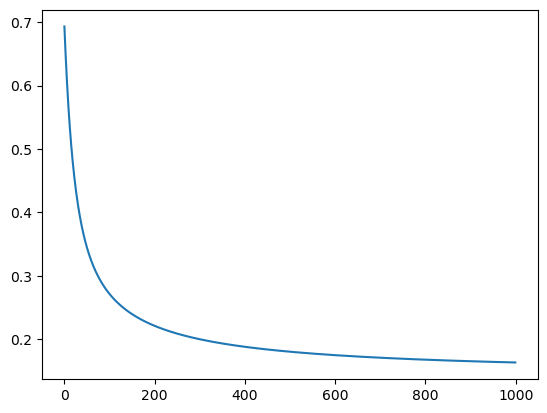

In [494]:
plt.plot(train_costs[::10])

In [495]:
#test

In [496]:
z_test = X_test.values @ w + b
a_test = sigmoid(z_test)
TN = FP = FN = TP = 0

In [497]:
y_true = Y_test.values.reshape(-1,1)
y_pred = (a_test >= 0.5).astype(int)

for i in range(len(y_true)):
    if y_true[i] == 1 and y_pred[i] == 1:
        TP += 1
    elif y_true[i] == 0 and y_pred[i] == 0:
        TN += 1
    elif y_true[i] == 0 and y_pred[i] == 1:
        FP += 1
    elif y_true[i] == 1 and y_pred[i] == 0:
        FN += 1

In [498]:
cm = np.array([[TN, FP],
               [FN, TP]])

print("Matrice de confusion :")
print(cm)

Matrice de confusion :
[[428   8]
 [ 27  37]]
